In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from gan_data_gen import load_data_for_wgan, get_mean_std_error
from wgan import compare_dfs
import numpy as np

In [2]:
maxepochs_range = [2000, 3000, 4000, 5000]
dropout_range = [0., 0.1, 0.2, 0.3]
batchsize = 256
lr = 1e-3

def get_train_data():
    df_train, _ = load_data_for_wgan('data/train.parquet')
    pos_vars = ["hh_wgt", "consumption_per_capita_per_day", "popdensity", "yearly_rent"]
    for var in pos_vars:
        df_train[var] = np.exp(df_train["log_" + var])
        df_train.drop(columns=["log_" + var], inplace=True)
    return df_train

def get_synthetic_data(maxepochs, lr, batchsize, dropout):
    df_synthetic = pd.read_parquet(f'data/synthetic-maxepochs={maxepochs}_lr={lr}_batchsize={batchsize}_dropout={dropout}_n=20000.parquet')
    return df_synthetic

df_train = get_train_data()


hparams = {}
for maxepochs in maxepochs_range:
        for dropout in dropout_range:
            df_synthetic = get_synthetic_data(maxepochs, lr, batchsize, dropout)
            mean_rmse, std_rmse = get_mean_std_error(df_train, df_synthetic)
            hparams[(maxepochs, dropout)] = (mean_rmse, std_rmse)

/home/users/rsahoo/zfs/gsb/intermediate-yens/rsahoo/poverty/dryrun/lib/python3.8/site-packages/wgan/wgan.py:66: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at ../aten/src/ATen/native/ReduceOps.cpp:1808.)
  self.stds  = [x.std(0,  keepdim=True) + 1e-5 for x in (continuous, context)]
/tmp/ipykernel_102571/3114996041.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_train[var] = np.exp(df_train["log_" + var])
/tmp/ipykernel_102571/3114996041.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once u

In [3]:
for maxepochs in maxepochs_range:
        for dropout in dropout_range:
                print(f'maxepochs={maxepochs}, dropout={dropout}: {hparams[(maxepochs, dropout)][0] + hparams[(maxepochs, dropout)][1] }')

maxepochs=2000, dropout=0.0: 0.14434985540767278
maxepochs=2000, dropout=0.1: 0.4272104473872891
maxepochs=2000, dropout=0.2: 0.3327711854701854
maxepochs=2000, dropout=0.3: 0.35383221909819385
maxepochs=3000, dropout=0.0: 0.11292028910223877
maxepochs=3000, dropout=0.1: 0.3124730883553385
maxepochs=3000, dropout=0.2: 0.2965091103383545
maxepochs=3000, dropout=0.3: 0.2905162214488807
maxepochs=4000, dropout=0.0: 0.11654645372716627
maxepochs=4000, dropout=0.1: 0.25886422849625157
maxepochs=4000, dropout=0.2: 0.31163212895999043
maxepochs=4000, dropout=0.3: 0.3003844215480488
maxepochs=5000, dropout=0.0: 0.08249259676961437
maxepochs=5000, dropout=0.1: 0.24418033507743508
maxepochs=5000, dropout=0.2: 0.3078155711584357
maxepochs=5000, dropout=0.3: 0.2969684673069922


In [4]:
df1 = get_train_data()
df2 = get_synthetic_data(5000, lr, batchsize, 0.0)

/home/users/rsahoo/zfs/gsb/intermediate-yens/rsahoo/poverty/dryrun/lib/python3.8/site-packages/wgan/wgan.py:66: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at ../aten/src/ATen/native/ReduceOps.cpp:1808.)
  self.stds  = [x.std(0,  keepdim=True) + 1e-5 for x in (continuous, context)]
/tmp/ipykernel_102571/3114996041.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_train[var] = np.exp(df_train["log_" + var])
/tmp/ipykernel_102571/3114996041.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once u

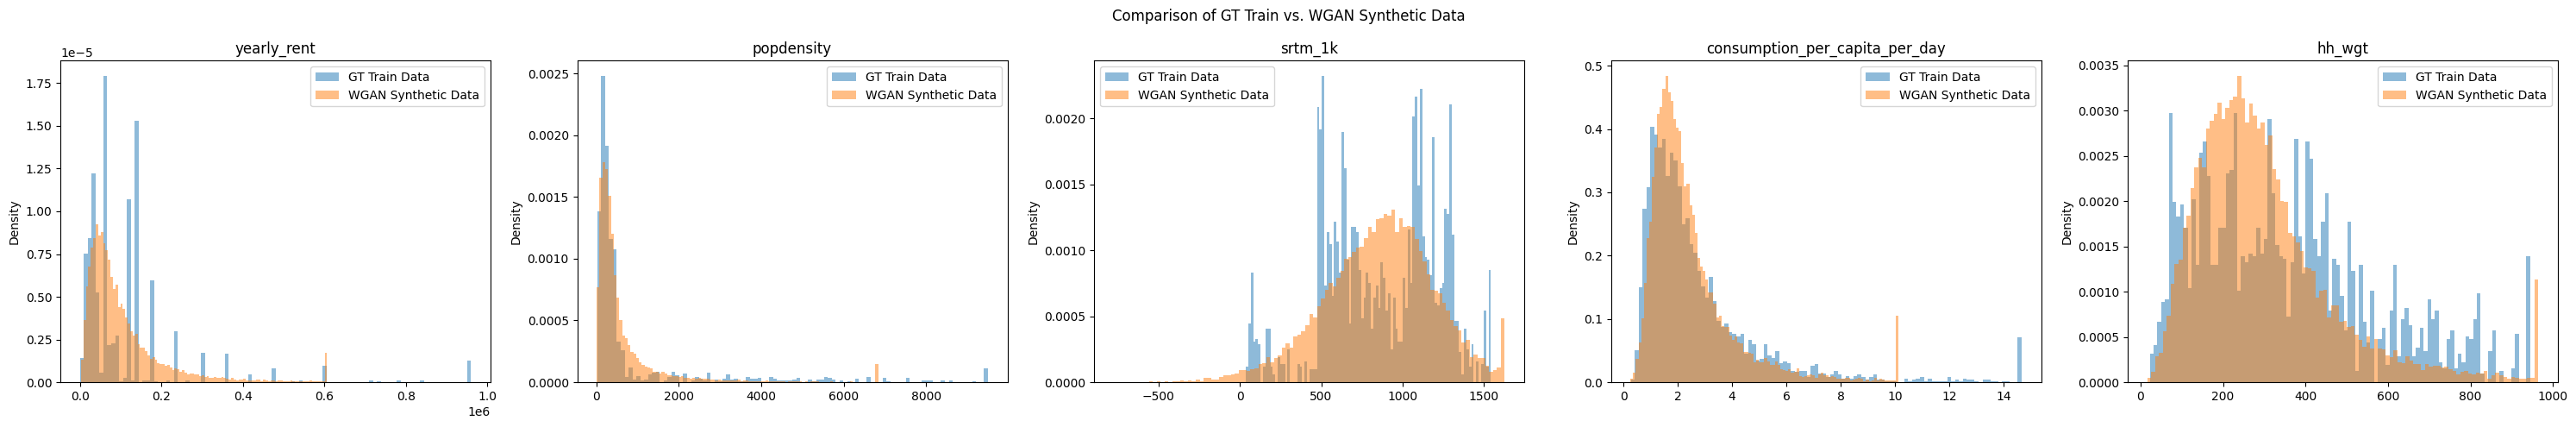

In [5]:
fig, axs = plt.subplots(1, 5, figsize=(30, 5))

features = ['yearly_rent', 'popdensity', 'srtm_1k', 'consumption_per_capita_per_day', 'hh_wgt']

plt.suptitle('Comparison of GT Train vs. WGAN Synthetic Data')

for i, feature in enumerate(features):
    axs[i].hist(np.clip(df1[feature], None, np.quantile(df1[feature], 0.99)), alpha=0.5, label='GT Train Data', density=True, bins=100)
    axs[i].hist(np.clip(df2[feature], None, np.quantile(df2[feature], 0.99)), alpha=0.5, label='WGAN Synthetic Data', density=True, bins=100)
    axs[i].set_title(feature)
    axs[i].set_ylabel('Density')
    axs[i].legend()
plt.tight_layout()
plt.savefig("figs/wgan.pdf")

